In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from scipy.signal import convolve
import scipy
from joblib import Parallel, delayed
import time
import sys
from scipy import sparse
import json
from tqdm import tqdm, tqdm_notebook
import matplotlib.gridspec as gridspec
import os
from scipy import stats
from copy import deepcopy
sys.path.insert(0, "../Scripts")
sys.path.insert(0, "../Long_Simulation")
# from antigenicWaveSimulationMethods import main as coEvoSimulation
from coverage import elementwise_coverage, coverage_1D
from fitness import fitness, norm_fitness, phage_growth
from altImmunity import immunity_loss_uniform, immunity_gain_from_kernel
from initMethods import init_trail_nh, init_1D_kernel, init_guassian_n, init_cond
from supMethods import time_conv, write2json, read_json
from mutation import mutation
from randomHGT import HGT_logistic_event
from formulas import gaussian1D, trail_exp

In [3]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    """Gaussian function."""
    normalization = 1/(sigma*np.sqrt(2*np.pi))
    return a *normalization*np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

def fit_gaussian(xdomain, data):
    """Fits a Gaussian to a 1D NumPy array and returns the optimal parameters.

    Args:
        data (np.array): The 1D array of data to fit.

    Returns:
        tuple: Optimal values for the amplitude (a), mean (x0), and standard deviation (sigma).
    """
    # Generate an x array that matches the indices of the data
    x = xdomain

    # Initial guesses for the parameters: amplitude (max of data), mean, and std deviation
    a_guess = np.max(data)
    x0_guess = np.sum(x * data) / np.sum(data)
    sigma_guess = np.sqrt(np.sum(data * (x - x0_guess) ** 2) / np.sum(data))

    # Fit the Gaussian model to the data
    popt, _ = curve_fit(gaussian, x, data, p0=[a_guess, x0_guess, sigma_guess])

    return popt

In [4]:
folder_2D = "../Data_Old/Data_Parallel/beta0_seed2"
t = 1860
n = sparse.load_npz(folder_2D+f"/sp_frame_n{t}.npz")
nh = sparse.load_npz(folder_2D+f"/sp_frame_nh{t}.npz")

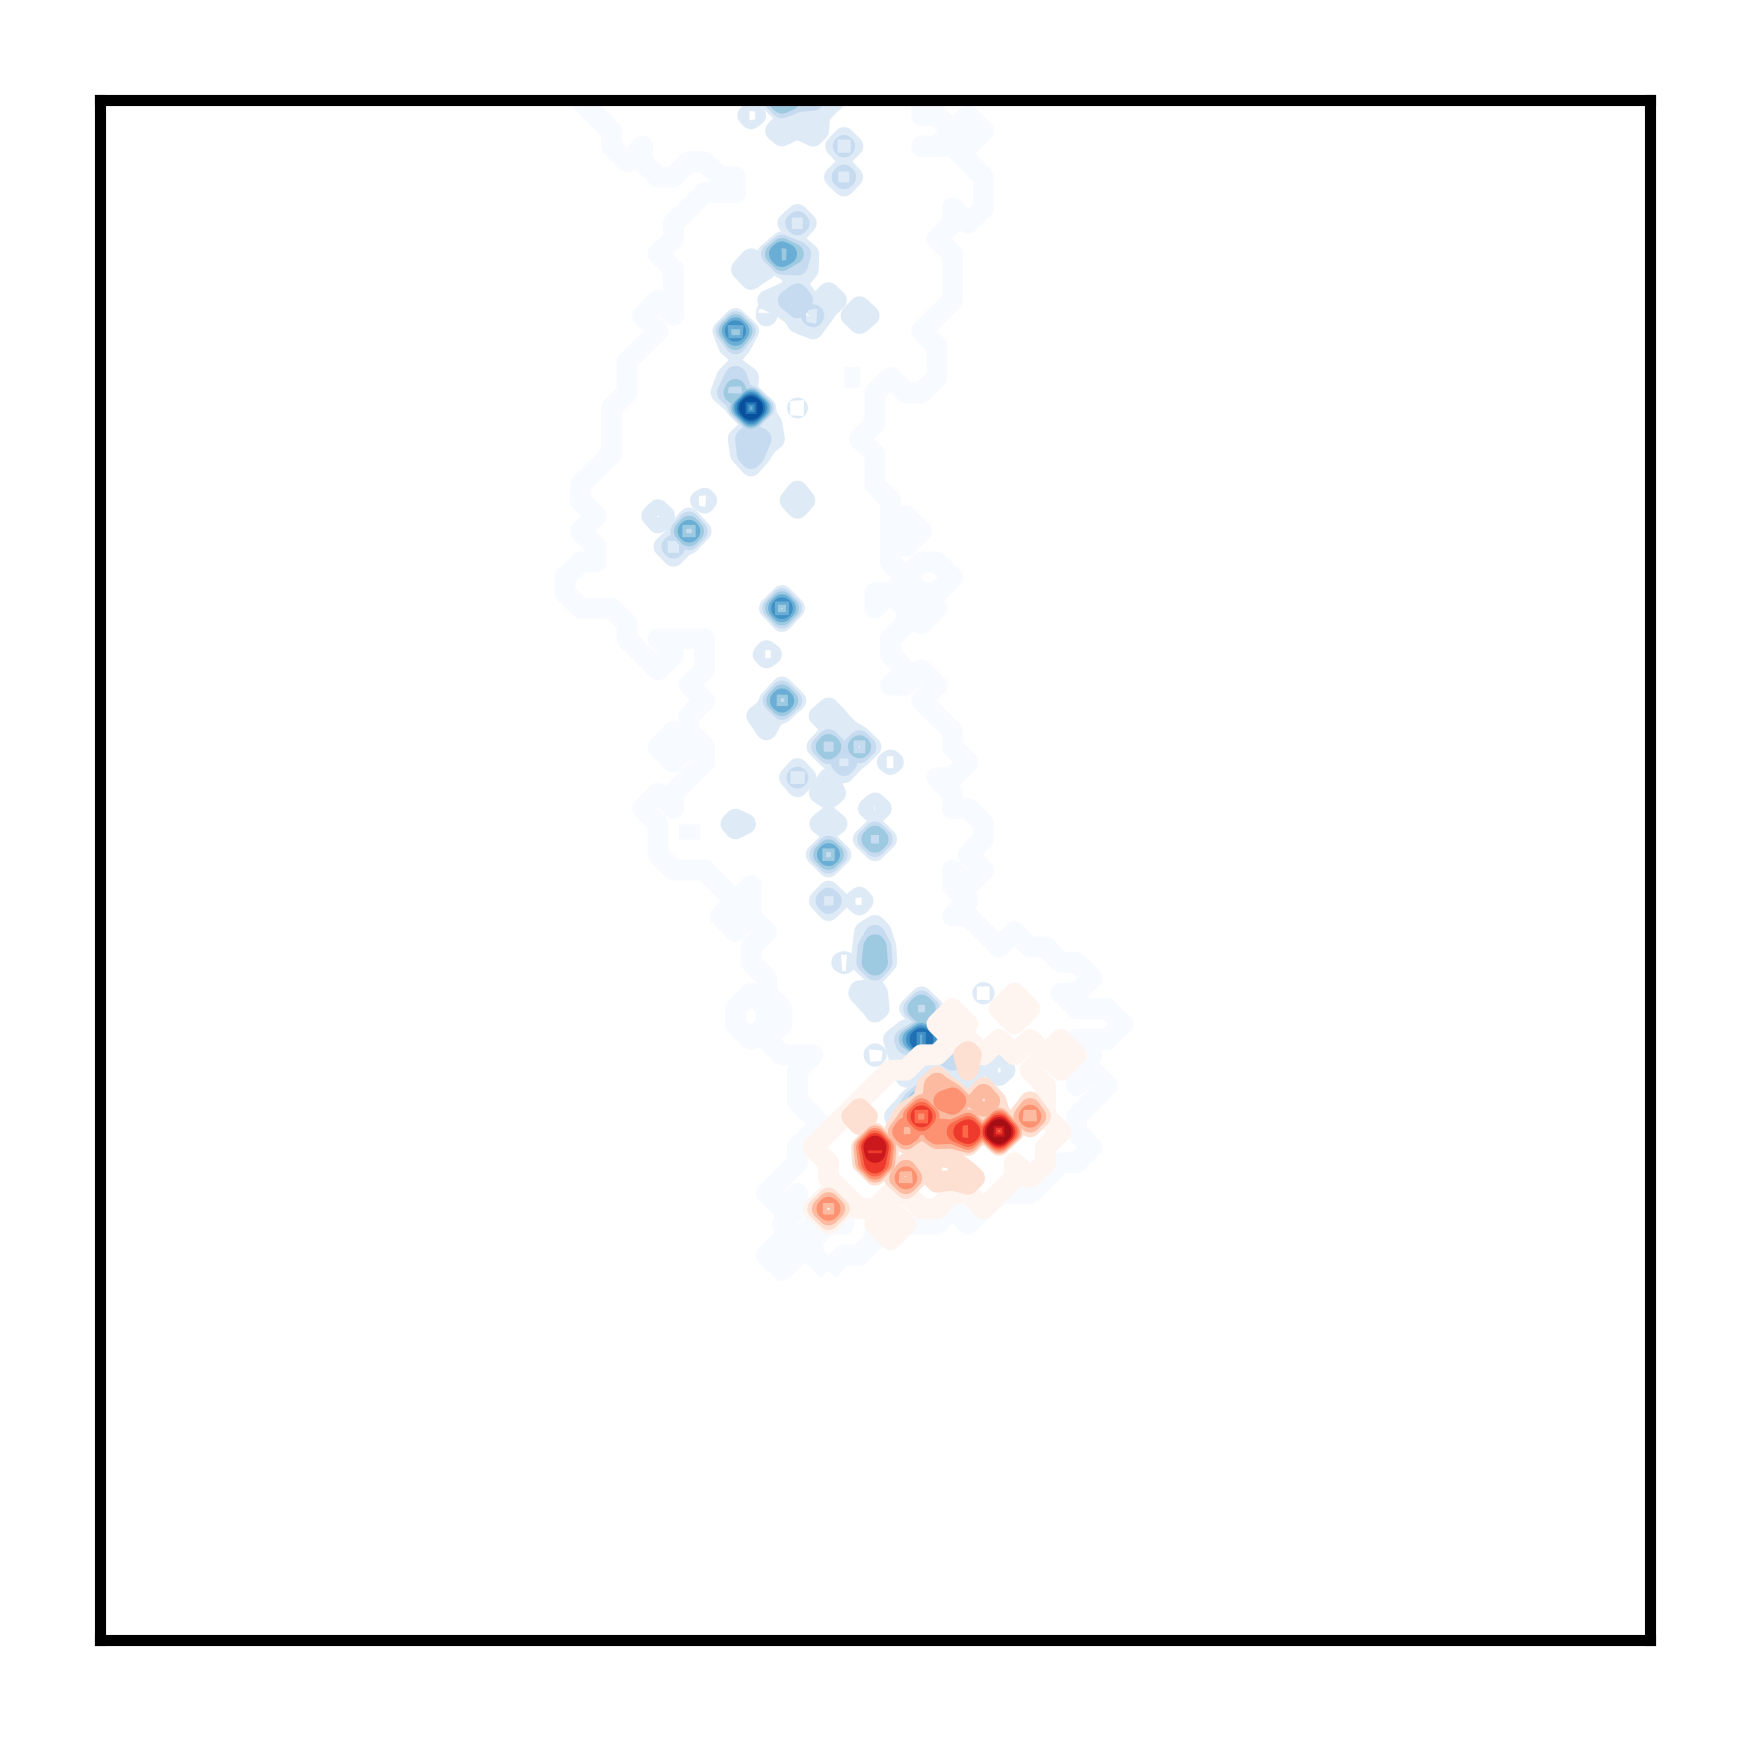

In [5]:
fig = plt.figure(figsize = (2,2),dpi = 1000)
plt.contour(nh.toarray().transpose(), cmap = "Blues")
plt.contour(n.toarray().transpose(), cmap = "Reds")
plt.ylim(875, 975)
plt.xlim(965, 1065)
plt.xticks([])
plt.yticks([])
# plt.colorbar()
plt.show()

In [6]:
folder_1D = "/home/zhi/Documents/Code/CRISPR_Sim/Data_2D_Test"
t = 0
n = sparse.load_npz(folder_1D+f"/sp_frame_n{t}.npz")
n = np.sum(n.toarray(), axis = 1)
nh = sparse.load_npz(folder_1D+f"/sp_frame_nh{t}.npz")
nh = np.sum(nh.toarray(), axis = 1)

t = 100
n_new = sparse.load_npz(folder_1D+f"/sp_frame_n{t}.npz")
n_new = np.sum(n_new.toarray(), axis = 1)
nh_new = sparse.load_npz(folder_1D+f"/sp_frame_nh{t}.npz")
nh_new = np.sum(nh_new.toarray(), axis = 1)


In [7]:
folder_1D = "/home/zhi/Documents/Code/CRISPR_Sim/Data_1D_Testing_A/Data_1D_Test_A_05"
t = 600
n = np.load(folder_1D+f"/frame_n{t}.npy")
nh = np.load(folder_1D+f"/frame_nh{t}.npy")

t = 605
n_new = np.load(folder_1D+f"/frame_n{t}.npy")
nh_new = np.load(folder_1D+f"/frame_nh{t}.npy")

In [8]:
params, sim_params = read_json(folder_1D)

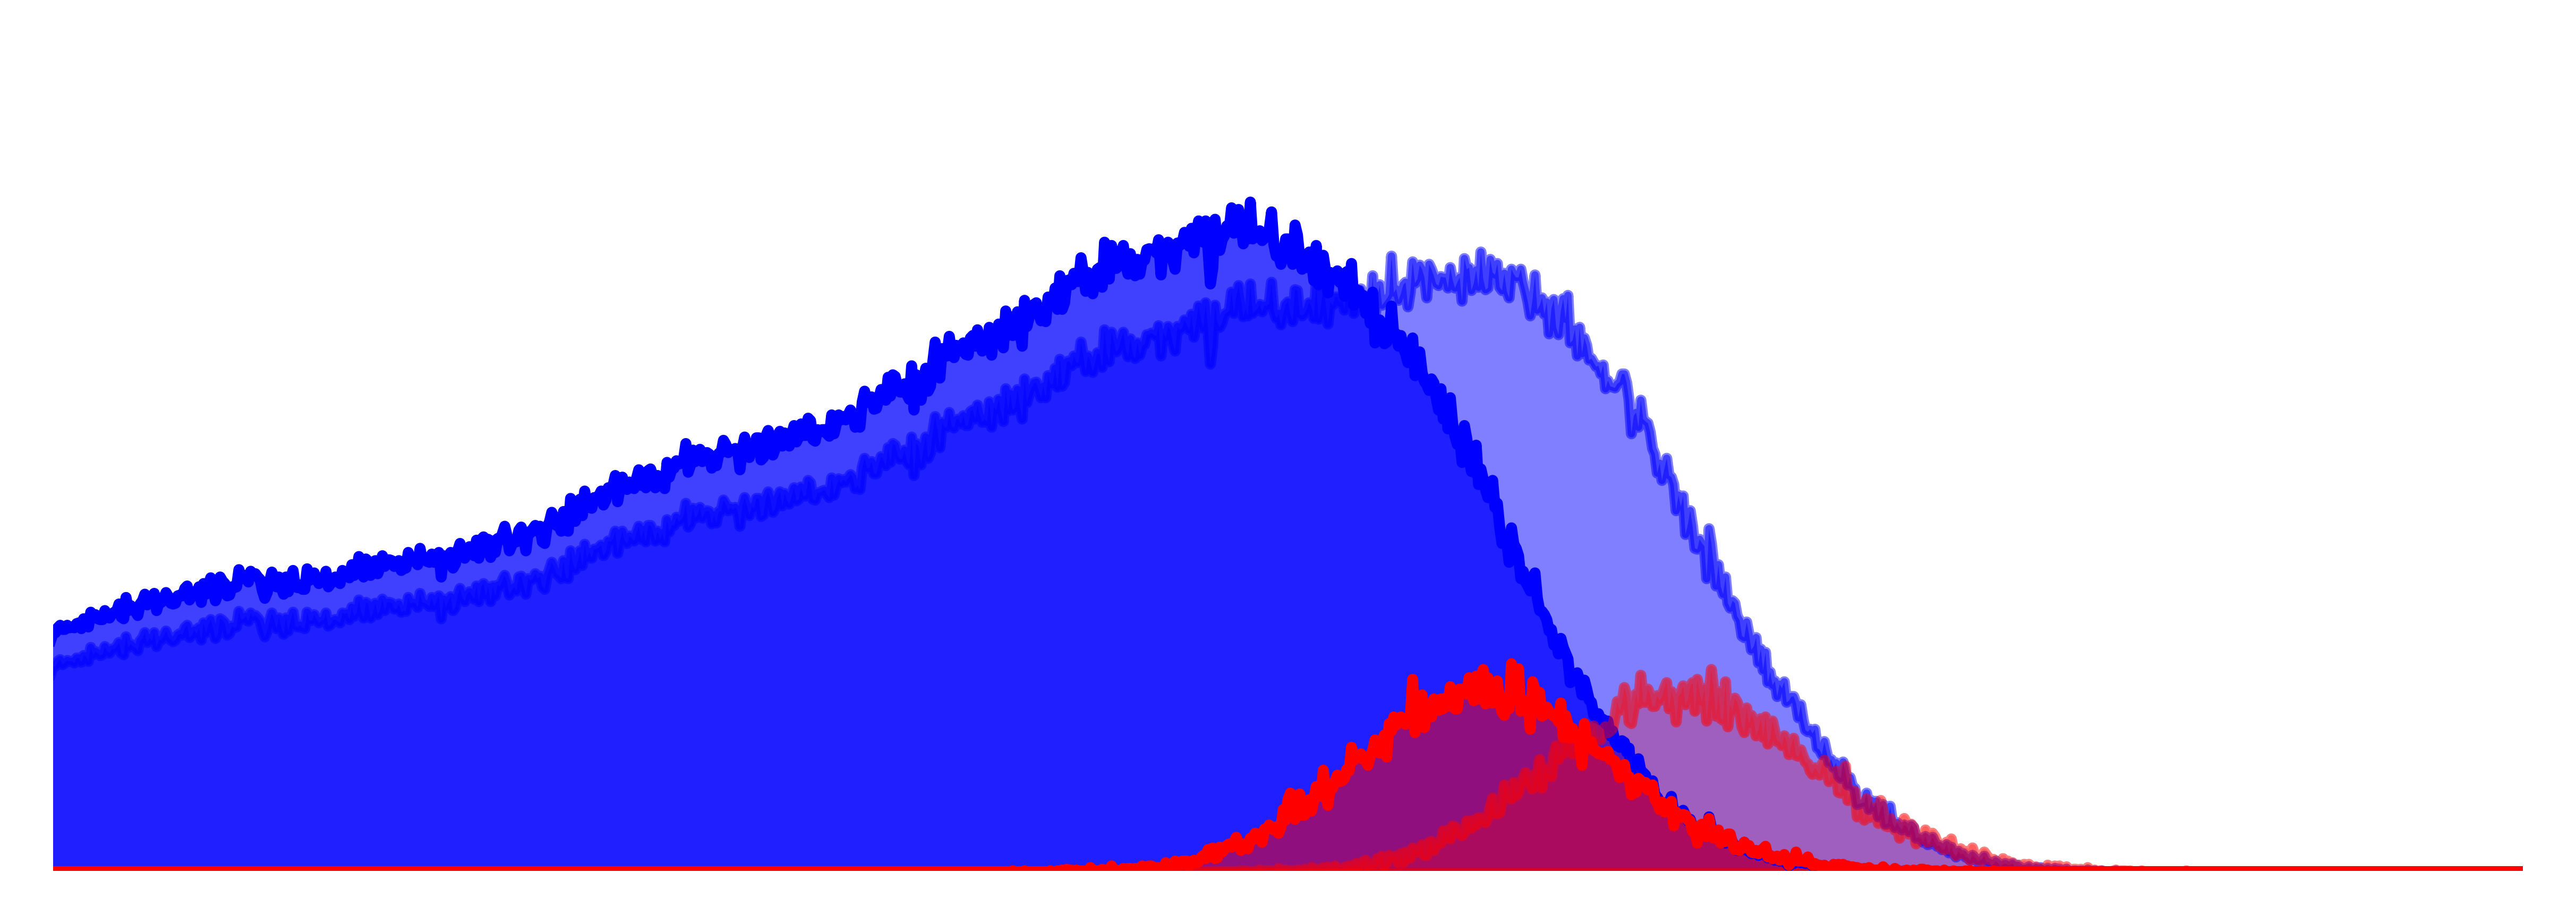

In [10]:
from formulas import gaussian1D, semi_exact_nh
xdomain = sim_params["xdomain"]
dx = sim_params["dx"]
x_range = np.arange(-xdomain, xdomain, dx)


fig = plt.figure(figsize=(6, 2),dpi = 1000)

# Define the grid layout with 3 rows and 3 columns
gs = gridspec.GridSpec(1, 1)

# Create the first two rows (2x2 grid)
ax1 = fig.add_subplot(gs[0, 0])
# ax1.set_title("Longitudinal")

ax1.plot(x_range, nh, color = "blue", label = f"actual Nh*M = {np.sum(nh)}")
ax1.fill_between(x_range, y1 = 0, y2 = nh,color ="blue", alpha = 0.75)
ax1.plot(x_range, nh_new, color = "blue", label = f"actual Nh*M = {np.sum(nh)}", alpha = 0.5)
ax1.fill_between(x_range, y1 = 0, y2 = nh_new,color ="blue", alpha = 0.5)

# ax1.plot(x_range, semi_exact_nh(x_range, 0, params, sim_params), linestyle = ":")
ax1.plot(x_range, n, color = "red", label = f"actual N= {np.sum(n)}")
ax1.fill_between(x_range, y1 = 0, y2 = n, alpha = 0.5, color = "red")

ax1.plot(x_range, n_new, color = "red", label = f"actual N= {np.sum(n)}", alpha = 0.5)
ax1.fill_between(x_range, y1 = 0, y2 = n_new, color = "red", alpha = 0.25)
# ax1.plot(x_range, gaussian1D(x_range, 0, params, sim_params), linestyle = ":")
# ax1.legend()

for spine in ax1.spines.values():
    spine.set_visible(False)


ax1.set_yticks([])
ax1.set_xticks([])
# ax1.set_yscale("log")
ax1.set_ylim(1, 1000)
ax1.set_xlim(9000, 10050)
plt.show()

In [11]:
list_to_sweep = np.power(10, np.arange(-1, 3, 0.25))
sim_params["foldername"] = "../Data_1D_mu"
superfolder = "../Data_1D_mu"
from antigenicWaveSimulation1DMethods import make_paramslists1D

def load_data_from_superfolder(superfolder, list_to_sweep, params_to_sweep):
    subfolders = [superfolder + "/" + params_to_sweep+ f"_{i}_seed0" for i in list_to_sweep]

    M_data = []
    mean_data = []
    error_data = []

    for folder in subfolders:

        params, sim_params = read_json(folder)
        M_data.append(params[params_to_sweep])

        N_time = []
        var_time = []
        x_time = []

        for t in range(sim_params["tf"]):
            try:
                nh = np.load(folder + f"/frame_nh{t}.npy")
                n = np.load(folder + f"/frame_n{t}.npy")
            except FileNotFoundError:
                break
            popt = fit_gaussian(x_range, n)
            N_time.append(popt[0])
            var_time.append(popt[2])
            x_time.append(popt[1])

        velocity = np.diff(x_time)
        means = [np.mean(N_time), np.mean(var_time), np.mean(velocity)]
        mean_data.append(means)

        errors = [np.std(N_time), np.std(var_time), np.std(velocity)]
        error_data.append(errors)

    M_data = np.array(M_data)
    mean_data = np.array(mean_data)
    error_data = np.array(error_data)
    return M_data, mean_data, error_data

def make_theoretical_curve(params, sim_params, param_to_sweep, list_to_sweep):
    params_list, sim_params_list = make_paramslists1D(params, sim_params, param_to_sweep, list_to_sweep)
    N = []
    sigma = []
    velocity = []

    for params, sim_params in zip(params_list, sim_params_list):
        params, sim_params = init_cond(params, sim_params, False, False)
        
        N.append(params["N"])
        sigma.append(params["sigma"])
        velocity.append(params["v0"])

    return np.array([N, sigma, velocity])

In [12]:
mu_data, mean_data, error_data = load_data_from_superfolder(superfolder, list_to_sweep, "mu")

In [13]:
list_to_sweep = np.power(10, np.arange(-1, 3, 0.25))
params["Nh"] = 1e6
sim_params["ndim"] = 2
params["M"]= 8
params["Np"] = 1000
params["dc"] = 100
Theory_Np_1000_dc_100_2 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

params["Np"] = 1000
params["dc"] = 10
Theory_Np_1000_dc_10_2 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

params["Np"] = 100
params["dc"] = 10
Theory_Np_100_dc_10_2 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

params["Nh"] = 1e6
sim_params["ndim"] = 1
params["M"]= 8
params["Np"] = 1000
params["dc"] = 100
Theory_Np_1000_dc_100_1 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

params["Np"] = 1000
params["dc"] = 10
Theory_Np_1000_dc_10_1 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

params["Np"] = 100
params["dc"] = 10
Theory_Np_100_dc_10_1 = make_theoretical_curve(params, sim_params, "mu", list_to_sweep)

Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16
Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16
Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16
Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16
Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16
Simulation to be done with Num of Threads: 1 for Num of Seeds: 1 and Num of Points: 16


In [62]:
mean_data.shape

(16, 3)

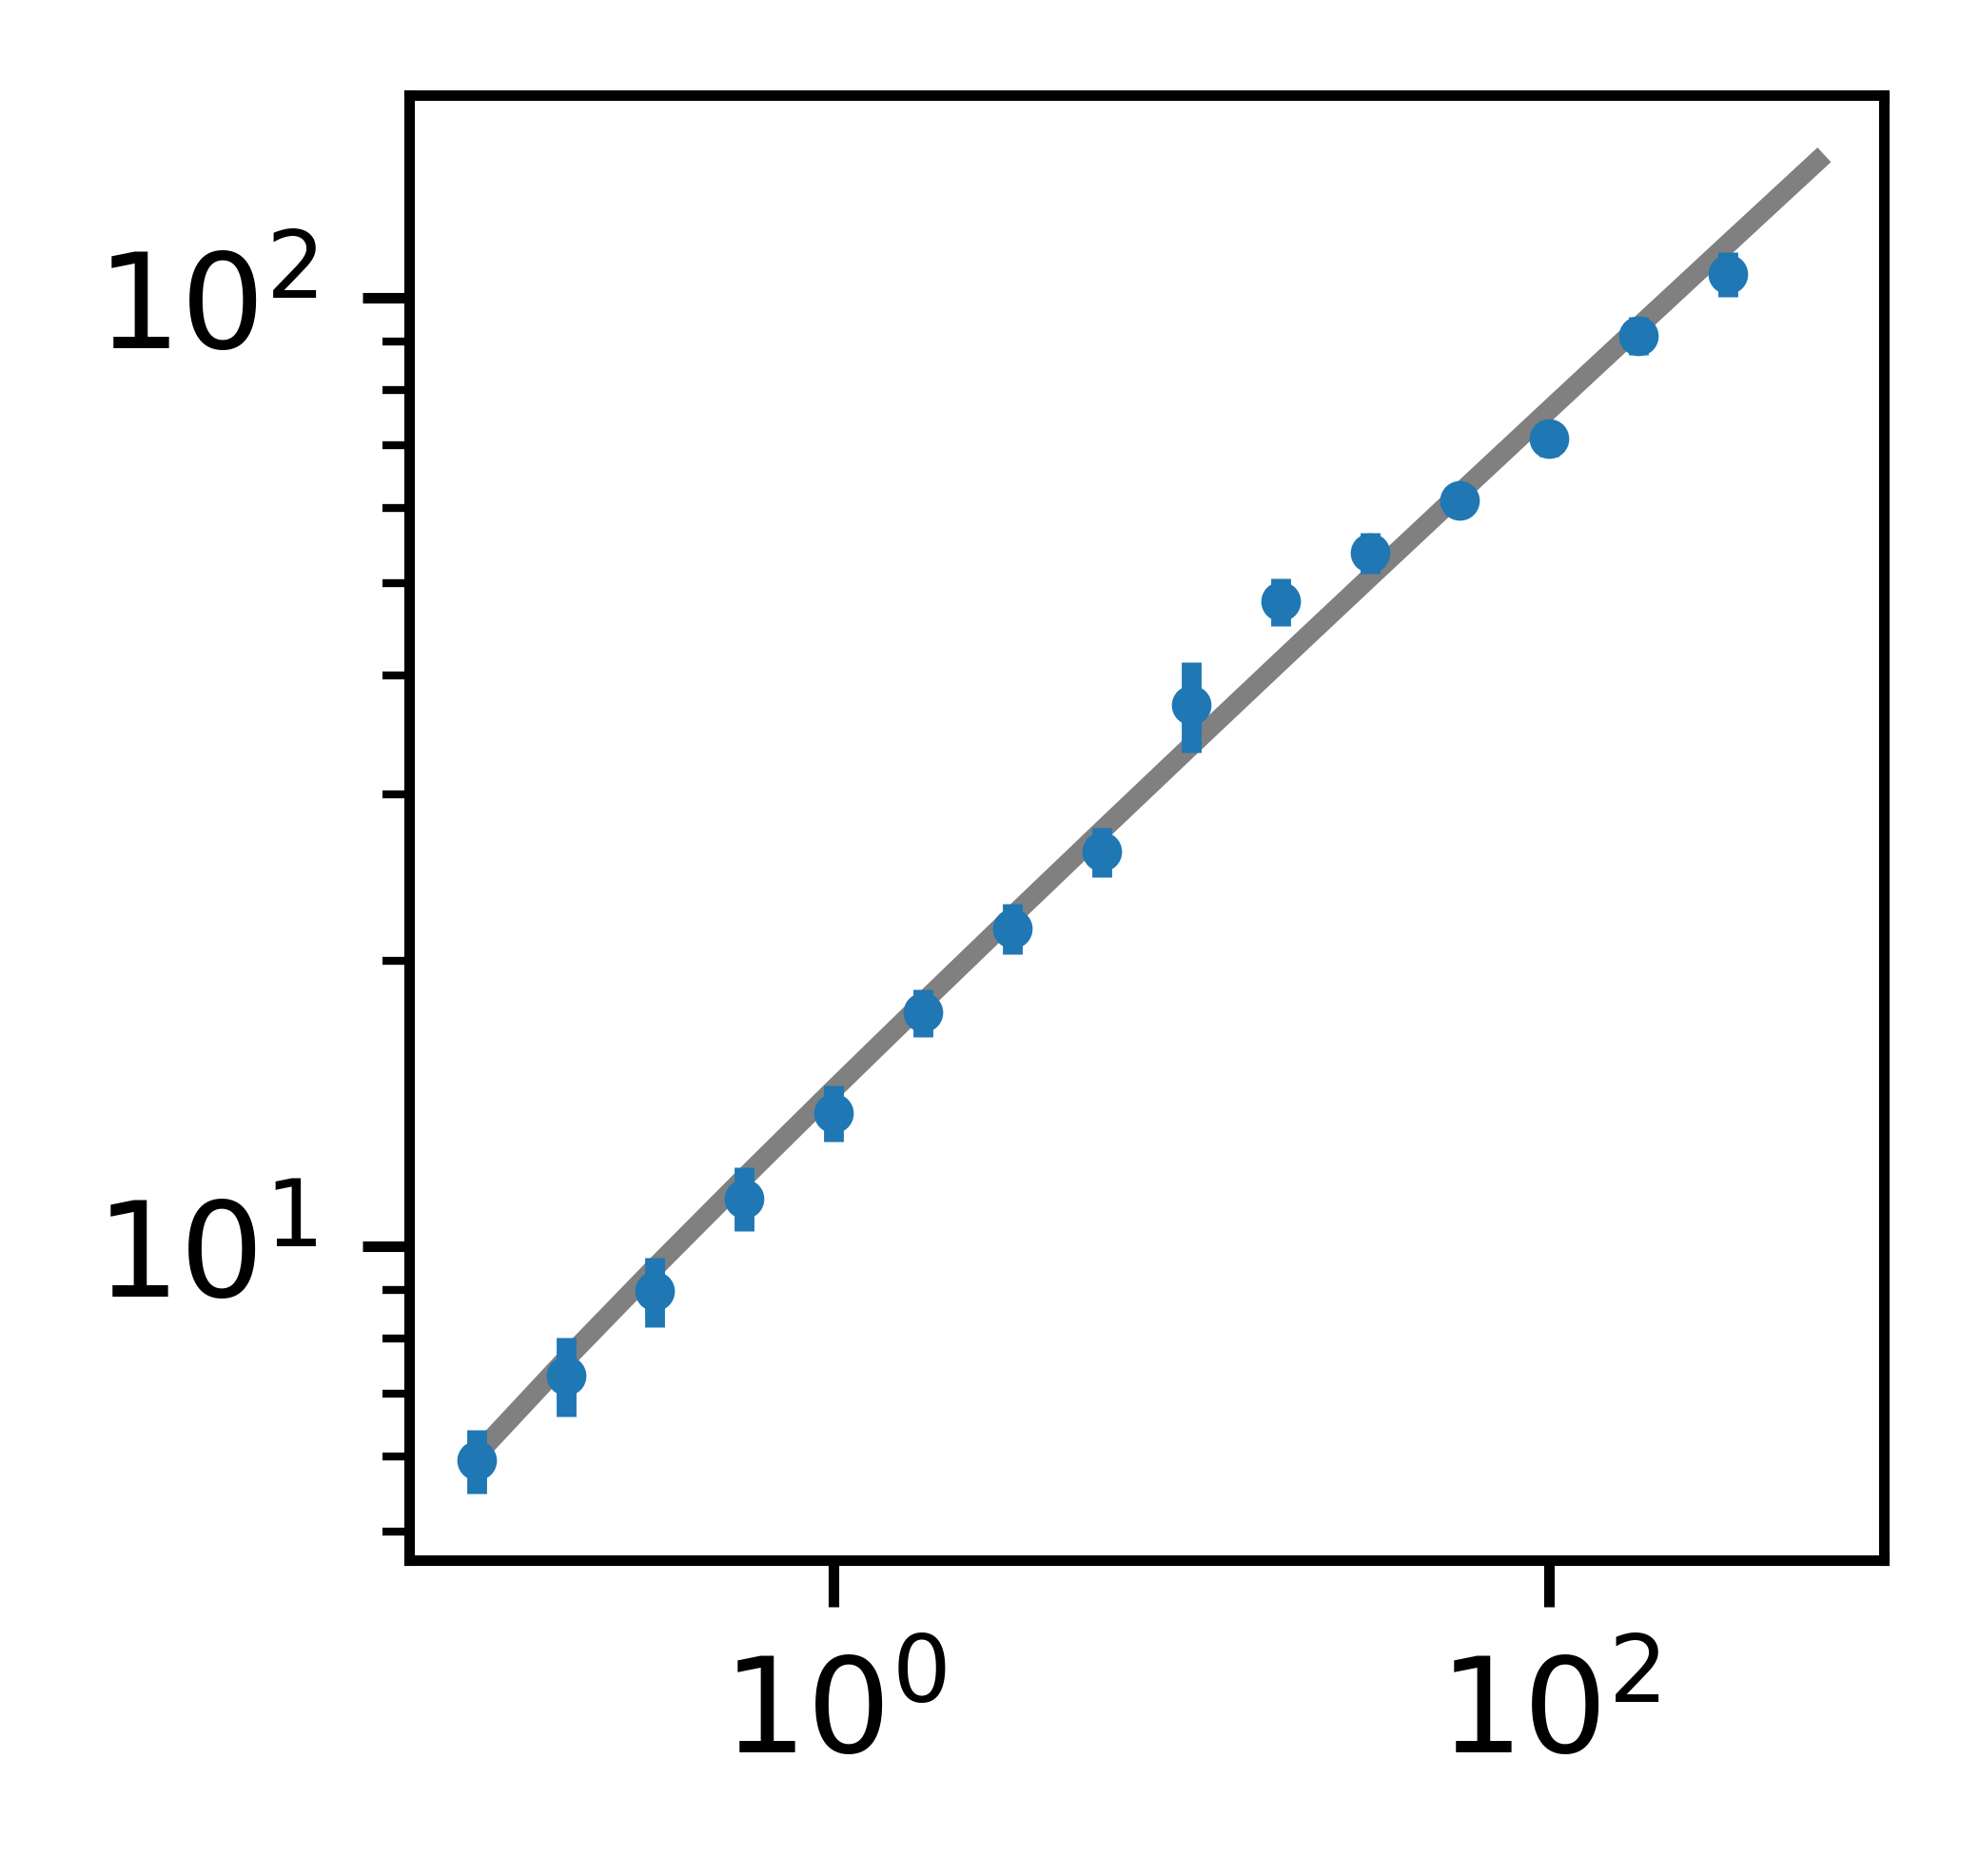

In [14]:
plt.figure(figsize=[2, 2], dpi = 1000)
plt.plot(list_to_sweep, Theory_Np_1000_dc_100_2[1, :], color = "grey", linestyle = "-")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_10_2[1, :], color = "grey", linestyle = "--")
# plt.plot(list_to_sweep, Theory_Np_100_dc_10_2[1, :], color = "grey", linestyle = ":")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_100_1[1, :], color = "black", linestyle = "-")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_10_1[1, :], color = "black", linestyle = "--")
# plt.plot(list_to_sweep, Theory_Np_100_dc_10_1[1, :], color = "black", linestyle = ":")
plt.errorbar(list_to_sweep[:-1], mean_data[:-1, 1], yerr=error_data[:-1, 1], linestyle = "none", fmt = "o", markersize = 2)
# plt.plot(list)
plt.xscale("log")
plt.yscale("log")

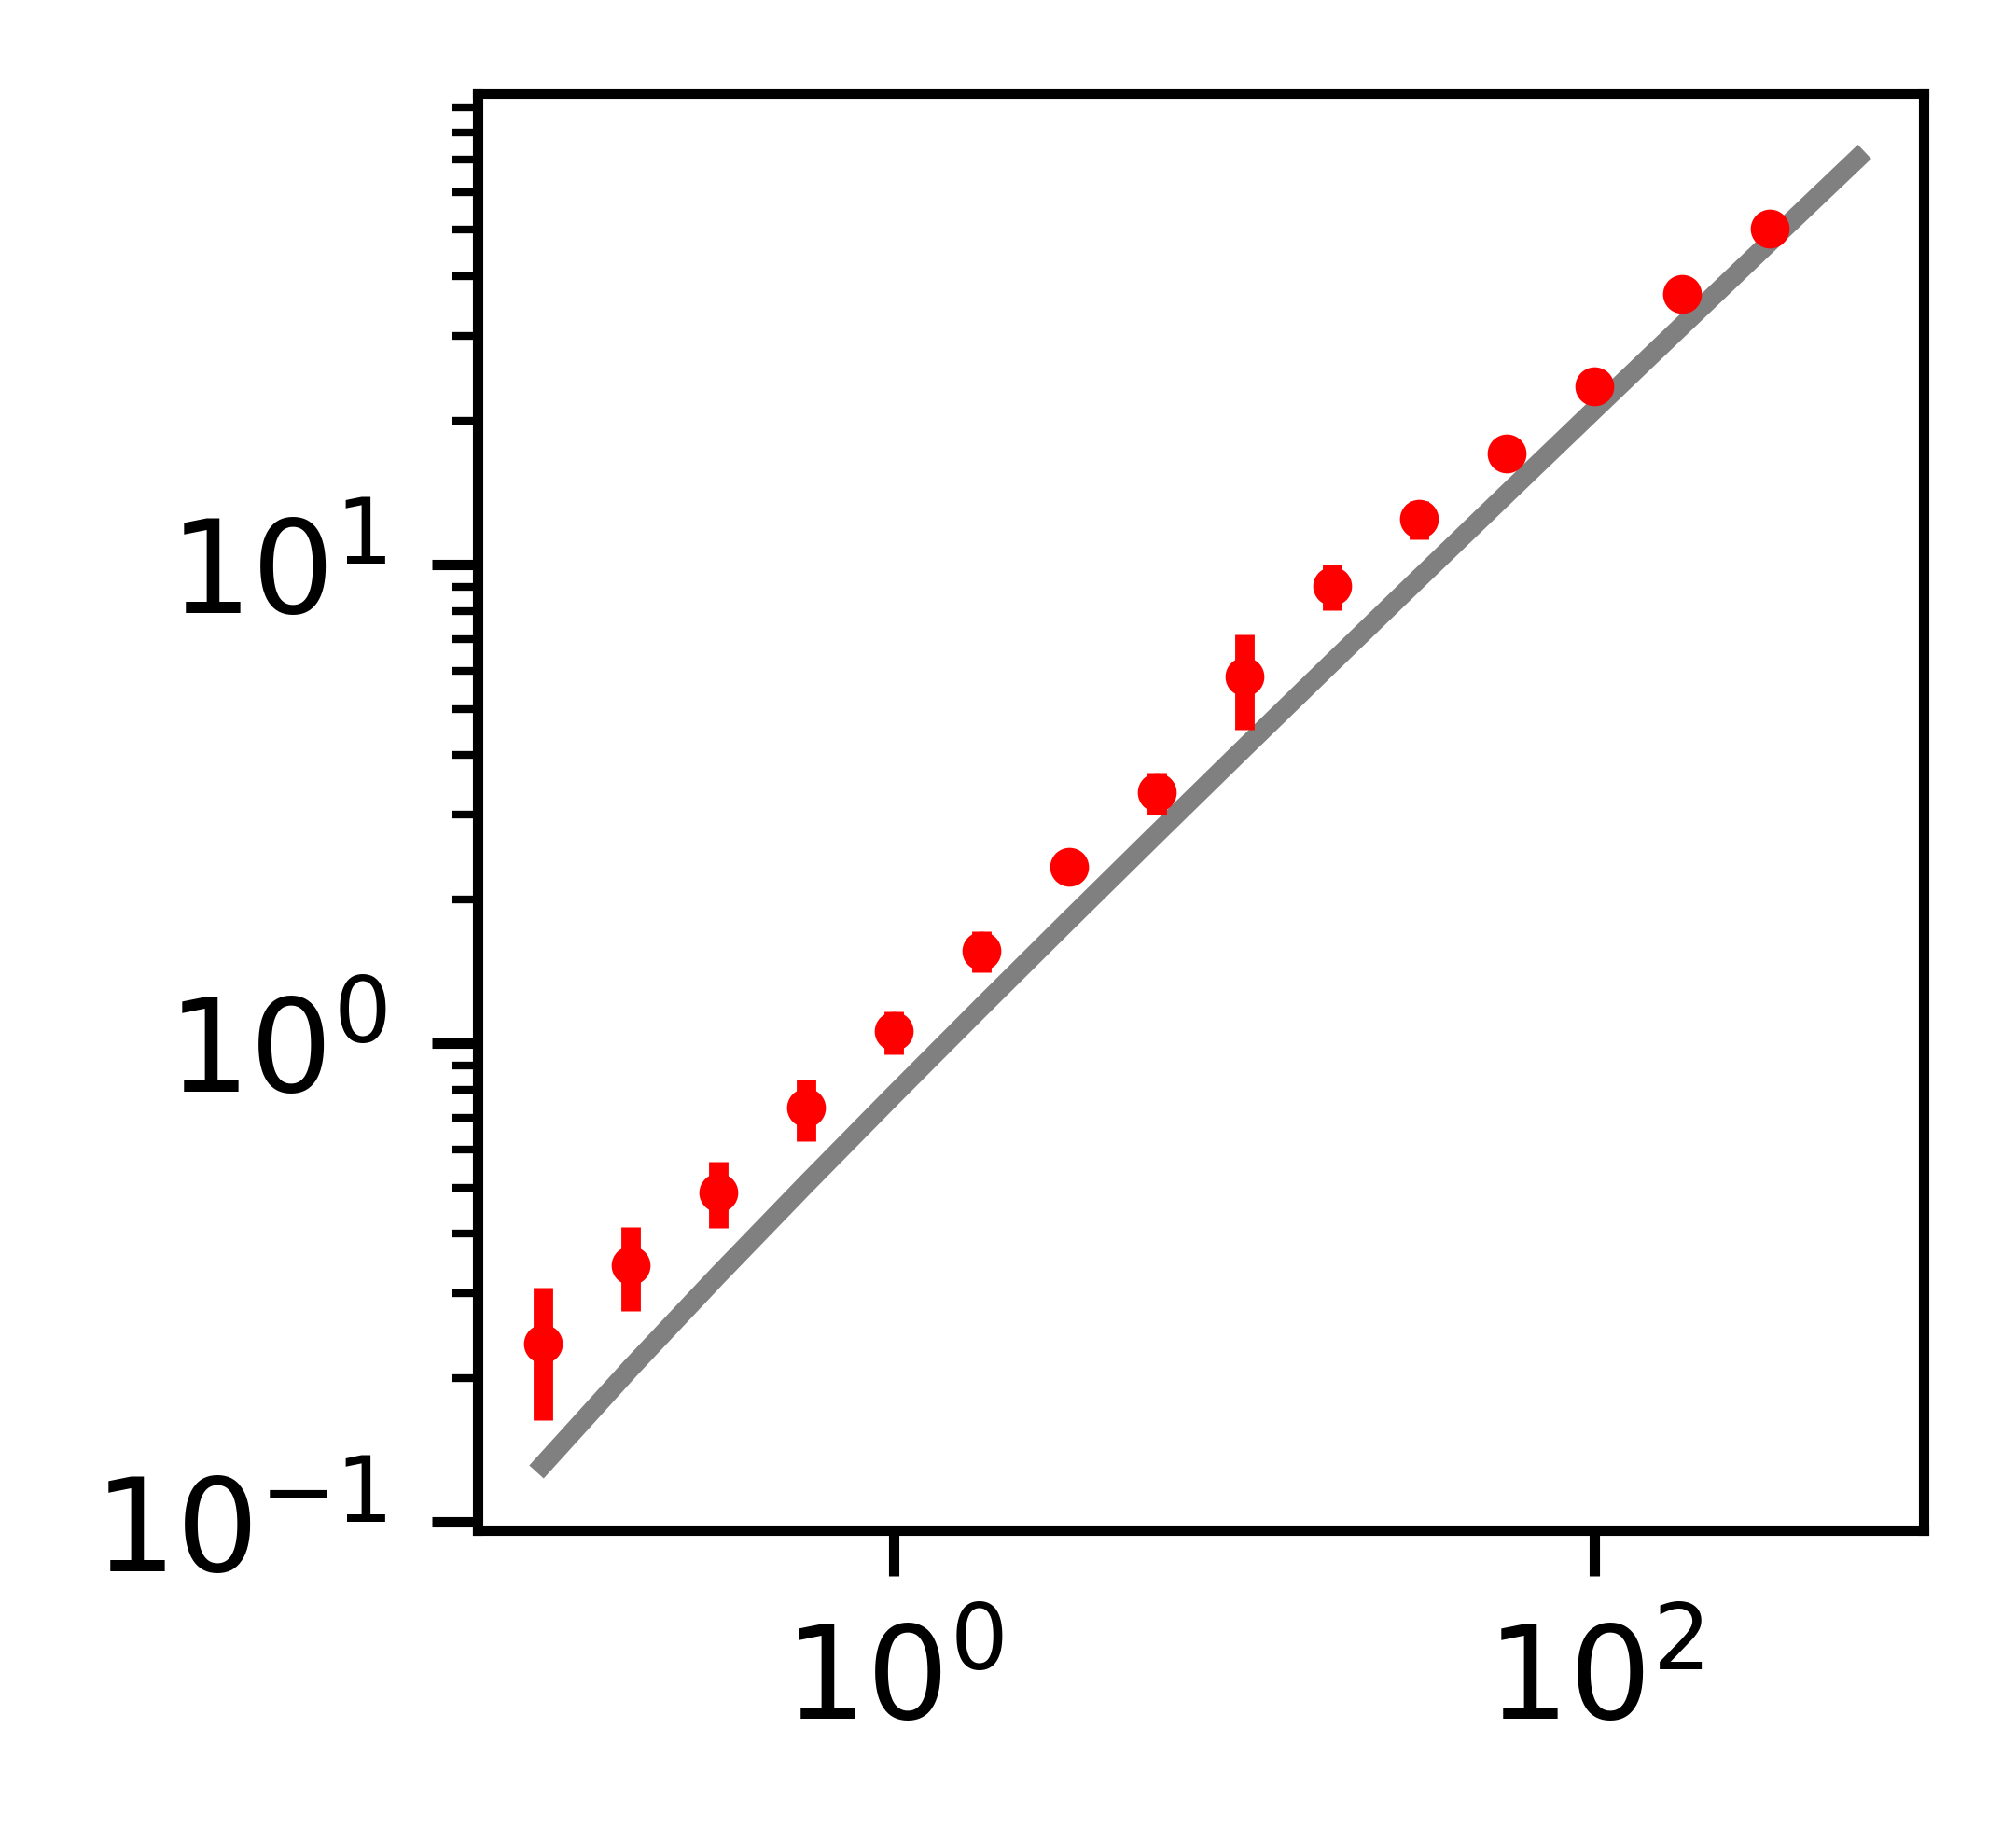

In [15]:
plt.figure(figsize=[2, 2], dpi = 1000)
plt.plot(list_to_sweep, Theory_Np_1000_dc_100_2[2, :], color = "grey", linestyle = "-")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_10_2[2, :], color = "grey", linestyle = "--")
# plt.plot(list_to_sweep, Theory_Np_100_dc_10_2[2, :], color = "grey", linestyle = ":")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_100_1[2, :], color = "black", linestyle = "-")
# plt.plot(list_to_sweep, Theory_Np_1000_dc_10_1[2, :], color = "black", linestyle = "--")
# plt.plot(list_to_sweep, Theory_Np_100_dc_10_1[2, :], color = "black", linestyle = ":")
plt.errorbar(list_to_sweep[:-1], mean_data[:-1, 2], yerr=error_data[:-1, 2], linestyle = "none", fmt = "o", markersize = 2, color = "red")
# plt.scatter(list_to_sweep[:-1], mean_data[:-1, 2], marker = "o", markersize = 20)
# plt.plot(list)
plt.xscale("log")
plt.yscale("log")